This notebook is to collect and make a single 2011 census small area file. 

In [88]:
import geopandas as gpd
import pandas as pd

import matplotlib.pyplot as plt
import contextily as cx

First England and Wales.

In [89]:
gdf_enw = gpd.read_file(r"C:\Users\spspa\OneDrive - The University of Liverpool\geographies\data\raw\census_2011\Lower_layer_Super_Output_Areas_Dec_2011_Boundaries_Full_Clipped_BFC_EW_V3_2022_-5365225720680633795.gpkg")

In [90]:
#Some cleanup
# Drop columns: 'BNG_E', 'BNG_N' and 4 other columns
gdf_enw = gdf_enw.drop(columns=['BNG_E', 'BNG_N', 'LONG_', 'LAT', 'Shape_Leng', 'GlobalID'])

# Clone column 'LSOA11CD' as 'data_zone_code11'
gdf_enw['data_zone_code11'] = gdf_enw.loc[:, 'LSOA11CD']
gdf_enw.head()

,LSOA11CD,LSOA11NM,geometry,data_zone_code11
0,E01000001,City of London 001A,"MULTIPOLYGON (((532151.537 181867.433, 532149....",E01000001
1,E01000002,City of London 001B,"MULTIPOLYGON (((532634.497 181926.016, 532632....",E01000002
2,E01000003,City of London 001C,"MULTIPOLYGON (((532153.703 182165.155, 532149....",E01000003
3,E01000005,City of London 001E,"MULTIPOLYGON (((533619.062 181402.364, 533615....",E01000005
4,E01000006,Barking and Dagenham 016A,"MULTIPOLYGON (((545126.852 184310.838, 545125....",E01000006


In [91]:
gdf_enw.shape

(34753, 4)

In [92]:
gdf_enw.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

Now load Northern Ireland

In [93]:
gdf_ni = gpd.read_file(r"C:\Users\spspa\OneDrive - The University of Liverpool\geographies\data\raw\census_2011\SA2011_Esri_Shapefile_0\SA2011.shp")

#Clean up - For Northern Ireland, in this vintage, NI had small areas, N = 4,537 (nested within super output areas ~ N= 890). A question I have here, is should we be using super output areas as equivalent to the other small geographies (viz LSOA) in the UK?

Image
SRC: https://www.nisra.gov.uk/files/nisra/publications/SAPaperJan2013_0.pdf#page=2.11

For now, I am keeping geographies for the SAs, and the codes for the SOAs in the Northern Ireland dataset - if needed, a simple dissolve should resolve this issue if we need it.


In [94]:
# Cleaning up 
# Drop columns: 'X_COORD', 'Y_COORD', 'Hectares'
gdf_ni = gdf_ni.drop(columns=['X_COORD', 'Y_COORD', 'Hectares'])

# Clone column 'SA2011' as 'data_zone_2011'
gdf_ni['data_zone_code11'] = gdf_ni.loc[:, 'SA2011']

In [95]:
gdf_ni.to_crs(gdf_enw.crs, inplace=True) # Harmonise the coordinate reference system of NI data to match ENW data

Scotland

In [96]:
gdf_scot = gpd.read_file(r"C:\Users\spspa\OneDrive - The University of Liverpool\geographies\data\raw\census_2011\SG_DataZoneBdry_2011\SG_DataZone_Bdry_2011.shp")

In [97]:
# Clean up
# Drop columns: 'TotPop2011', 'ResPop2011' and 5 other columns
gdf_scot = gdf_scot.drop(columns=['TotPop2011', 'ResPop2011', 'HHCnt2011', 'StdAreaHa', 'StdAreaKm2', 'Shape_Leng', 'Shape_Area'])

# Clone column 'DataZone' as 'data_zone_code11'
gdf_scot['data_zone_code11'] = gdf_scot.loc[:, 'DataZone']

<Axes: >

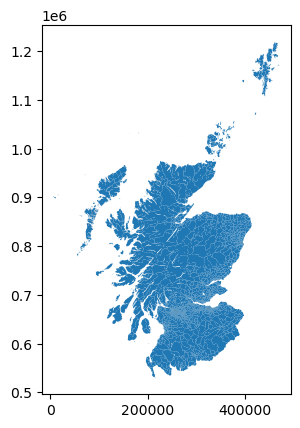

In [98]:
gdf_scot.plot()

Now, to combine them. I am adding a country column for ease. 

In [99]:
gdf_enw["country_name"] = gdf_enw["LSOA11CD"].str[:1]
gdf_enw["country_name"] = gdf_enw["country_name"].str.replace({"E":"England","W":"Wales"}).copy()

In [100]:
gdf_ni["country_name"] = "Northern Ireland"
gdf_scot["country_name"] = "Scotland"

In [101]:
combined = gpd.GeoDataFrame(
    pd.concat([gdf_enw, gdf_ni, gdf_scot], ignore_index=True),
    crs=gdf_enw.crs
)

In [102]:
combined.columns

Index(['LSOA11CD', 'LSOA11NM', 'geometry', 'data_zone_code11', 'country_name',
       'SA2011', 'SOA2011', 'DataZone', 'Name'],
      dtype='str')

In [103]:
combined = combined.rename(columns={
    "DataZone": "so_dz_code",
    "Name" : "so_dz_name",
    "LSOA11CD": "enw_LSOA11CD",
    "LSOA11NM": "enw_LSOA11NM",
    "SA2011" : "ni_SA2011",
    "SOA2011": "ni_SOA2011",

})

In [79]:
combined.columns

Index(['enw_LSOA11CD', 'enw_LSOA11NM', 'geometry', 'data_zone_code11',
       'country_name', 'ni_SA2011', 'ni_SOA2011', 'so_dz_code', 'so_dz_name'],
      dtype='str')

In [107]:
import numpy as np

In [109]:
combined["name11"] = np.nan

In [ ]:
combined["name11"] = combined["name11"].fillna(combined["enw_LSOA11NM"])
combined["name11"] = combined["name11"].fillna(combined["so_dz_name"])

In [ ]:
combined["name11"].isna().sum() # Only the northern ireland names are missing now. 

np.int64(4537)

In [120]:
combined.head()

,enw_LSOA11CD,enw_LSOA11NM,geometry,data_zone_code11,country_name,ni_SA2011,ni_SOA2011,so_dz_code,so_dz_name,name11
0,E01000001,City of London 001A,"MULTIPOLYGON (((532151.537 181867.433, 532149....",E01000001,England,NaN,NaN,NaN,NaN,City of London 001A
1,E01000002,City of London 001B,"MULTIPOLYGON (((532634.497 181926.016, 532632....",E01000002,England,NaN,NaN,NaN,NaN,City of London 001B
2,E01000003,City of London 001C,"MULTIPOLYGON (((532153.703 182165.155, 532149....",E01000003,England,NaN,NaN,NaN,NaN,City of London 001C
3,E01000005,City of London 001E,"MULTIPOLYGON (((533619.062 181402.364, 533615....",E01000005,England,NaN,NaN,NaN,NaN,City of London 001E
4,E01000006,Barking and Dagenham 016A,"MULTIPOLYGON (((545126.852 184310.838, 545125....",E01000006,England,NaN,NaN,NaN,NaN,Barking and Dagenham 016A


In [61]:
combined[["data_zone_code11", "country_name","enw_LSOA11CD", "enw_LSOA11NM", "geometry"]]

,data_zone_code11,country_name,enw_LSOA11CD,enw_LSOA11NM,geometry
0,E01000001,England,E01000001,City of London 001A,"MULTIPOLYGON (((532151.537 181867.433, 532149...."
1,E01000002,England,E01000002,City of London 001B,"MULTIPOLYGON (((532634.497 181926.016, 532632...."
2,E01000003,England,E01000003,City of London 001C,"MULTIPOLYGON (((532153.703 182165.155, 532149...."
3,E01000005,England,E01000005,City of London 001E,"MULTIPOLYGON (((533619.062 181402.364, 533615...."
4,E01000006,England,E01000006,Barking and Dagenham 016A,"MULTIPOLYGON (((545126.852 184310.838, 545125...."
...,...,...,...,...,...
46261,S01013477,Scotland,NaN,NaN,"POLYGON ((308686 672220, 308688 672191, 308708..."
46262,S01013478,Scotland,NaN,NaN,"POLYGON ((307423.889 672579.756, 307424.594 67..."
46263,S01013479,Scotland,NaN,NaN,"POLYGON ((308478 672440, 308485 672434, 308488..."
46264,S01013480,Scotland,NaN,NaN,"POLYGON ((308734 672598, 308743 672543, 308905..."


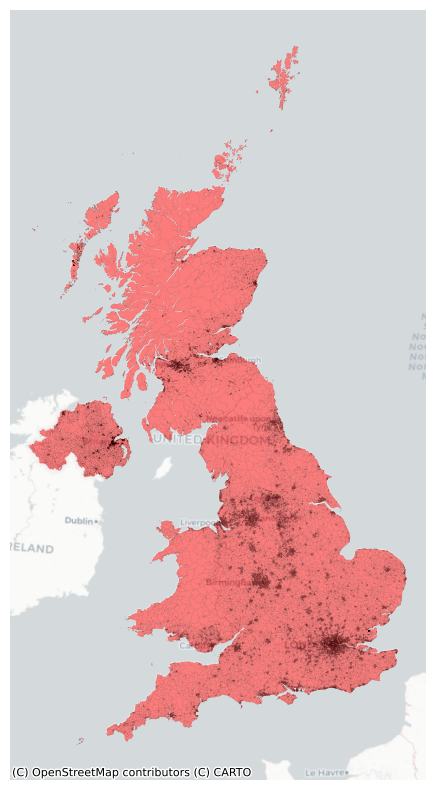

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

combined.plot(ax=ax, alpha=0.5, color="red", edgecolor="black", linewidth=0.05)

# add basemap - combined must be in a projected CRS (e.g. Web Mercator, EPSG:3857)
cx.add_basemap(ax, crs=combined.crs, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.show()